# TP : Reconstruction d’une image scintigraphique cardiaque

Belgheir Imene - groupe 1

**Objectif général :**  
Simuler et reconstruire une image scintigraphique représentant un cœur à l’aide de deux méthodes principales (**FBP** et **SART**), puis appliquer un débruitage et détecter les **zones froides**.  
On comparera les résultats en termes de qualité visuelle et à l’aide de métriques quantitatives.

**Bibliothèques utilisées :**
- `numpy`, `matplotlib` : manipulation de données et affichage.
- `scikit-image` : pour la transformée de Radon, les reconstructions, les métriques et le débruitage.
- `scipy` : pour le filtrage (Gaussian, etc.).


In [56]:
# Importation des bibliothèques
import numpy as np
import matplotlib.pyplot as plt
from skimage import transform, metrics, restoration
from skimage.util import random_noise
from skimage.draw import disk
from scipy.ndimage import gaussian_filter
from skimage.filters import threshold_otsu


# 1) Création du phantom scintigraphique

**But :** créer une image simple représentant un cœur avec une **zone froide** (faible activité).  
On crée donc :
- un grand disque blanc (le cœur),
- un petit disque noir à l’intérieur (zone froide),
- puis on lisse les bords avec un filtre gaussien pour un rendu plus réaliste.


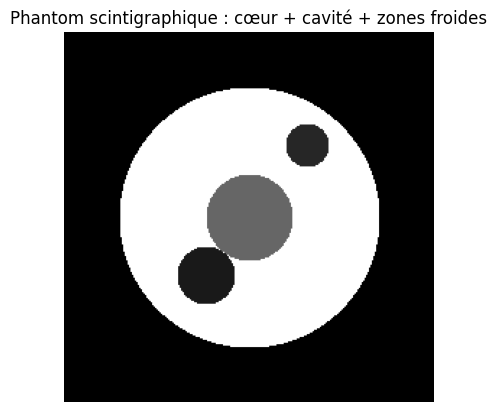

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.draw import disk
from scipy.ndimage import gaussian_filter

# Create empty image
size = 256
phantom = np.zeros((size, size))

# --- 1. Main heart (bright) ---
center = (size // 2, size // 2)
heart_radius = 90
rr, cc = disk(center, heart_radius)
phantom[rr, cc] = 1.0  # normal active region (bright)

# --- 2. Heart cavity (middle gray) ---
# This represents the left ventricular cavity (normal, not a cold zone)
cavity_center = (size // 2, size // 2)
cavity_radius = 30
rr_cav, cc_cav = disk(cavity_center, cavity_radius)
phantom[rr_cav, cc_cav] = 0.4  # mid intensity (lower normal uptake)

# --- 3. Cold zones (pathological areas) ---
# Cold zone 1
cold_center1 = (size // 2 + 40, size // 2 - 30)
cold_radius1 = 20
rr_cold1, cc_cold1 = disk(cold_center1, cold_radius1)
phantom[rr_cold1, cc_cold1] = 0.1  # low activity

# Cold zone 2 (optional, different area)
cold_center2 = (size // 2 - 50, size // 2 + 40)
cold_radius2 = 15
rr_cold2, cc_cold2 = disk(cold_center2, cold_radius2)
phantom[rr_cold2, cc_cold2] = 0.15


plt.imshow(phantom, cmap='gray')
plt.title("Phantom scintigraphique : cœur + cavité + zones froides")
plt.axis('off')
plt.show()


# 2) Ajout du bruit (bruit de Poisson)

**Pourquoi ?**  
En scintigraphie, le bruit provient du caractère aléatoire du comptage de photons.  
Le bruit suit donc une loi de **Poisson**.

**Fonction utilisée :**  
`skimage.util.random_noise(image, mode='poisson')`


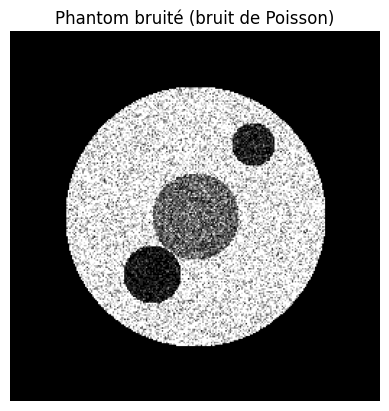

In [58]:
noisy_phantom = random_noise(phantom, mode='poisson')

plt.imshow(noisy_phantom, cmap='gray')
plt.title("Phantom bruité (bruit de Poisson)")
plt.axis('off')
plt.show()


# 3) Calcul du sinogramme (Transformée de Radon)

**Principe :**  
On simule les projections acquises par la caméra gamma à différents angles.

**Fonction :**  
`transform.radon(image, theta, circle=True)`

- `image` : l’image à transformer.  
- `theta` : angles en degrés (0° → 180°).  
- `circle=True` : limite le domaine à l’intérieur du disque.

**Observation attendue :**  
Le sinogramme contient les “ombres” de l’objet vues sous tous les angles :  
les structures circulaires apparaissent comme des courbes sinusoïdales.


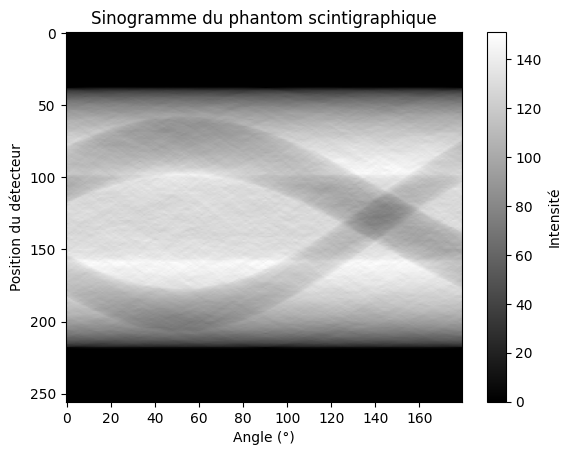

In [59]:
n_angles = 180
theta = np.linspace(0., 180., n_angles, endpoint=False)
sinogram = transform.radon(noisy_phantom, theta=theta, circle=True)

plt.imshow(sinogram, cmap='gray', aspect='auto')
plt.title("Sinogramme du phantom scintigraphique")
plt.xlabel("Angle (°)")
plt.ylabel("Position du détecteur")
plt.colorbar(label='Intensité')
plt.show()


# 4) Reconstruction de l’image

Nous utilisons deux méthodes :

### a) FBP — Filtered Back Projection
- Méthode rapide, classique.  
- Reprojette toutes les projections en appliquant un filtrage fréquentiel.
- **Fonction :** `transform.iradon(sinogram, theta, filter_name='ramp', circle=True)`

Paramètres :
- `filter_name` peut être `'ramp'`, `'hann'`, `'cosine'`, etc.
- `circle=True` limite la reconstruction au disque utile.

### b) SART — Simultaneous Algebraic Reconstruction Technique
- Méthode itérative : compare projections réelles et simulées, puis corrige l’image.
- **Fonction :** `transform.iradon_sart(sinogram, theta, image=...)`


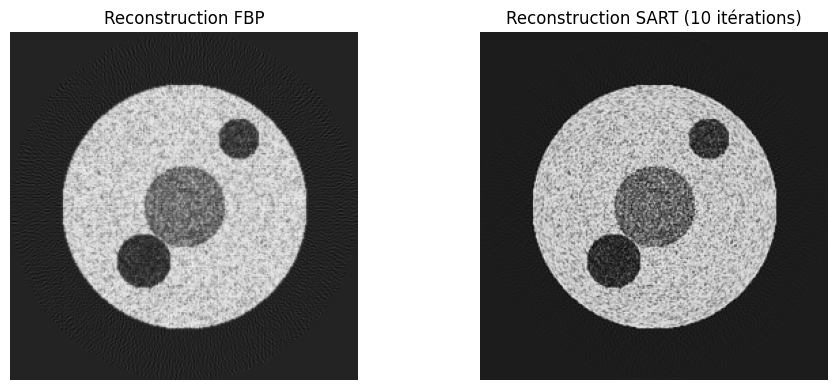

In [60]:
# Reconstruction FBP
recon_fbp = transform.iradon(sinogram, theta=theta, filter_name='ramp', circle=True)

# Reconstruction SART (10 itérations)
recon_sart = transform.iradon_sart(sinogram, theta=theta)
for i in range(9):
    recon_sart = transform.iradon_sart(sinogram, theta=theta, image=recon_sart)

# Affichage
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(recon_fbp, cmap='gray')
axes[0].set_title("Reconstruction FBP")
axes[0].axis('off')

axes[1].imshow(recon_sart, cmap='gray')
axes[1].set_title("Reconstruction SART (10 itérations)")
axes[1].axis('off')

plt.tight_layout()
plt.show()


# 5) Débruitage des reconstructions

**Pourquoi ?**  
Les reconstructions restent bruitées à cause du comptage statistique (Poisson).  
On applique un débruitage modéré, ici le **filtrage TV (Total Variation)**.

**Fonction :**  
`restoration.denoise_tv_chambolle(image, weight=...)`

- `weight` contrôle la force du lissage (0.1 → peu de lissage, 0.5 → plus fort).  
- Évite de déformer les bords tout en réduisant le bruit.


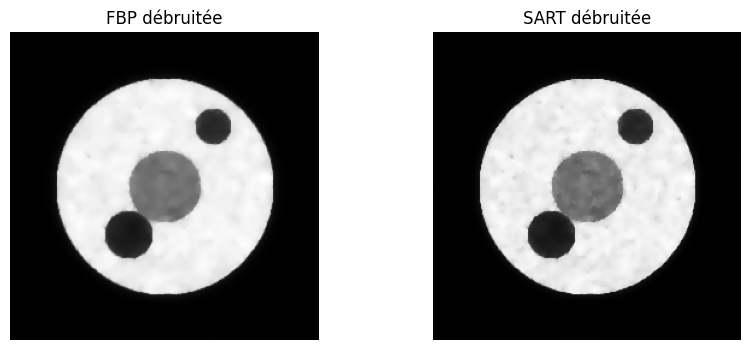

In [61]:
recon_fbp_denoised = restoration.denoise_tv_chambolle(recon_fbp, weight=0.2)
recon_sart_denoised = restoration.denoise_tv_chambolle(recon_sart, weight=0.2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(recon_fbp_denoised, cmap='gray')
axes[0].set_title("FBP débruitée")
axes[0].axis('off')

axes[1].imshow(recon_sart_denoised, cmap='gray')
axes[1].set_title("SART débruitée")
axes[1].axis('off')
plt.show()


# 6) Détection automatique des zones froides

**Principe :**  
Les zones froides correspondent à des régions à **intensité faible**.  
On peut les détecter par **seuillage**.

**Méthode :**
- On calcule un seuil global (`threshold_otsu`) puis on le rend plus strict (×0.6).
- Les pixels dont l’intensité est inférieure à ce seuil sont considérés “froids”.


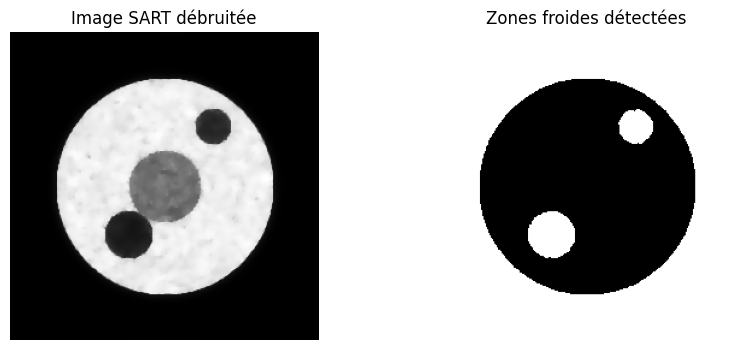

In [62]:
# Détection sur SART (plus précis en général)
th = threshold_otsu(recon_sart_denoised)
cold_mask = recon_sart_denoised < th * 0.6

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(recon_sart_denoised, cmap='gray')
plt.title("Image SART débruitée")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cold_mask, cmap='gray')
plt.title("Zones froides détectées")
plt.axis('off')
plt.show()


# 7) Évaluation quantitative

**Métriques utilisées :**
- **MSE (Mean Squared Error)** : moyenne des erreurs au carré.
- **PSNR (Peak Signal-to-Noise Ratio)** : rapport signal/bruit, en dB.
- **SSIM (Structural Similarity)** : similarité perceptuelle (0–1).
- **MAE (Mean Absolute Error)** : erreur absolue moyenne.
- **Erreur relative (%)** : différence moyenne relative à la valeur de référence.

Toutes sont calculées entre la reconstruction et le phantom original.


In [63]:
def relative_error(true, pred):
    return np.mean(np.abs(true - pred) / np.maximum(true, 1e-8))

# Calcul métriques
mse_fbp = metrics.mean_squared_error(phantom, recon_fbp_denoised)
mse_sart = metrics.mean_squared_error(phantom, recon_sart_denoised)

psnr_fbp = metrics.peak_signal_noise_ratio(phantom, recon_fbp_denoised)
psnr_sart = metrics.peak_signal_noise_ratio(phantom, recon_sart_denoised)

ssim_fbp = metrics.structural_similarity(phantom, recon_fbp_denoised, data_range=1.0)
ssim_sart = metrics.structural_similarity(phantom, recon_sart_denoised, data_range=1.0)

mae_fbp = np.mean(np.abs(phantom - recon_fbp_denoised))
mae_sart = np.mean(np.abs(phantom - recon_sart_denoised))

err_fbp = relative_error(phantom, recon_fbp_denoised)
err_sart = relative_error(phantom, recon_sart_denoised)

print("---- FBP ----")
print(f"MSE  = {mse_fbp:.6f}")
print(f"PSNR = {psnr_fbp:.2f} dB")
print(f"SSIM = {ssim_fbp:.4f}")
print(f"MAE  = {mae_fbp:.4f}")
print(f"Erreur relative = {err_fbp*100:.2f}%\n")

print("---- SART ----")
print(f"MSE  = {mse_sart:.6f}")
print(f"PSNR = {psnr_sart:.2f} dB")
print(f"SSIM = {ssim_sart:.4f}")
print(f"MAE  = {mae_sart:.4f}")
print(f"Erreur relative = {err_sart*100:.2f}%")


---- FBP ----
MSE  = 0.008778
PSNR = 20.57 dB
SSIM = 0.9020
MAE  = 0.0542
Erreur relative = 34854836.20%

---- SART ----
MSE  = 0.008100
PSNR = 20.92 dB
SSIM = 0.8908
MAE  = 0.0520
Erreur relative = 26126415.82%


# 8) Observations et interprétation

- Le **sinogramme** représente toutes les projections mesurées sous différents angles.  
- **FBP** : reconstruction rapide, mais présente souvent des artefacts de rayons (streaks) et une sensibilité au bruit.  
- **SART** : plus lent (itératif), mais plus précis et plus robuste en présence de bruit ou de données limitées.  
- Le **débruitage TV** a permis d’améliorer le contraste tout en conservant la forme du cœur.  
- La **détection des zones froides** par seuillage fonctionne bien : la région sombre du phantom est correctement identifiée sur la reconstruction SART.  
- Les **métriques** (MSE plus bas, PSNR et SSIM plus élevés pour SART) confirment la meilleure qualité de cette méthode.


# Conclusion

Ce TP a permis de :
- Simuler une image scintigraphique cardiaque simple avec une zone froide.
- Reproduire le processus d’acquisition (sinogramme), reconstruction (FBP, SART), et débruitage.
- Comparer quantitativement les performances des deux méthodes.

**Résultats principaux :**
- FBP → rapide mais bruité et sensible aux artefacts.  
- SART → plus lent mais plus fidèle à la réalité.  
- Le seuillage d’intensité a permis d’isoler clairement la zone froide.

**En pratique :**
Dans une application médicale réelle, des algorithmes itératifs (type SART, OSEM) et des techniques de régularisation sont privilégiés pour obtenir des images plus nettes et fiables tout en minimisant le bruit statistique.

---
